# Sustainable Development Goal 11: Sustainable Cities and Communities

This Jupyter Notebook focuses on the development and preparation of the SDG 11 Sub-Index, which relates to the United Nations Sustainable Development Goal 11: Good Health and Well-Being.

The purpose of this notebook is to import, inspect, clean and prepare datasets associated with sustainable cities and communities indicators for use in a larger composite indicator project. The processed data will later contribute towards calculating a comparative SDG readiness score across countries.

The following datasets are obtained through: https://unstats.un.org/sdgs/dataportal/ 

**Disclaimer: This dataset has already been standardised by the UN SDG database, therefore some common data cleaning steps such as formatting corrections, unit conversions and major transformations were not required. The cleaning process mainly focused on handling missing values, identifying duplicates, selecting relevant indicators and preparing the data for analysis.**

### 1.1 Import Data

In [120]:
# Import pandas
import pandas as pd

# Load datasets
slum_df = pd.read_excel("EN_LND_SLUM.xlsx")
disaster_df = pd.read_excel("VC_DSR_DAFF.xlsx")

# Display first 5 rows of each dataframe
print("Urban Slum Dataset:")
display(slum_df.head())

print("\nDisaster Affected Dataset:")
display(disaster_df.head())

Urban Slum Dataset:


,Goal,Target,Indicator,SeriesCode,SeriesDescription,GeoAreaCode,GeoAreaName,Location,Reporting Type,Units,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,11,11.1,11.1.1,EN_LND_SLUM,Proportion of urban population living in slums...,4,Afghanistan,URBAN,G,PERCENT,...,NaN,72.12863,NaN,73.30000,NaN,73.30000,NaN,71.58904,NaN,NaN
1,11,11.1,11.1.1,EN_LND_SLUM,Proportion of urban population living in slums...,8,Albania,URBAN,G,PERCENT,...,NaN,7.80000,NaN,5.30000,NaN,2.80000,NaN,2.70000,NaN,NaN
2,11,11.1,11.1.1,EN_LND_SLUM,Proportion of urban population living in slums...,12,Algeria,URBAN,G,PERCENT,...,NaN,21.07581,NaN,17.17042,NaN,13.26502,NaN,13.24600,NaN,NaN
3,11,11.1,11.1.1,EN_LND_SLUM,Proportion of urban population living in slums...,20,Andorra,URBAN,G,PERCENT,...,NaN,0.00000,NaN,0.00000,NaN,0.00000,NaN,0.00000,0.0,0.0
4,11,11.1,11.1.1,EN_LND_SLUM,Proportion of urban population living in slums...,24,Angola,URBAN,G,PERCENT,...,NaN,56.44953,NaN,62.58105,NaN,62.60000,NaN,62.70000,NaN,NaN



Disaster Affected Dataset:


,Goal,Target,Indicator,SeriesCode,SeriesDescription,GeoAreaCode,GeoAreaName,Reporting Type,Units,2005,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,1,1.5,1.5.1,VC_DSR_DAFF,Number of directly affected persons attributed...,4,Afghanistan,G,PER_100000_POP,NaN,...,NaN,69.052215,24.728493,765.247448,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1.5,1.5.1,VC_DSR_DAFF,Number of directly affected persons attributed...,8,Albania,G,PER_100000_POP,0.357589,...,5.279745,0.172518,161.804638,19.999931,NaN,NaN,4796.574923,817.004585,471.207283,NaN
2,1,1.5,1.5.1,VC_DSR_DAFF,Number of directly affected persons attributed...,12,Algeria,G,PER_100000_POP,0.732241,...,2.232519,34.901043,58.796101,3.624013,237.341138,299.195067,143.642811,53.441823,95.039320,NaN
3,1,1.5,1.5.1,VC_DSR_DAFF,Number of directly affected persons attributed...,20,Andorra,G,PER_100000_POP,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,244.879786,0.000000,NaN
4,1,1.5,1.5.1,VC_DSR_DAFF,Number of directly affected persons attributed...,24,Angola,G,PER_100000_POP,54.351317,...,257.992048,128.318858,106.003245,1239.651476,240.544924,0.622603,109.120158,1.567351,10.209617,0.06916


#### Meaning of Datasets:

- slum_df : Proportion of urban population living in slums (%) EN_LND_SLUM
- disaster_df : Number of directly affected persons attributed to disasters per 100,000 population (number) VC_DSR_DAFF

#### 2.1 Select Columns

In [121]:
# Select columns for each dataset

# Years
years_2000_2024 = [str(year) for year in range(2000, 2025)]
years_2005_2025 = [str(year) for year in range(2005, 2026)]

# Clean column names
slum_df.columns = slum_df.columns.str.strip()
disaster_df.columns = disaster_df.columns.str.strip()

# slum_df columns
slum_df = slum_df[['GeoAreaName'] + years_2000_2024]

# disaster_df columns
disaster_df = disaster_df[['GeoAreaName'] + years_2005_2025]

# Display first 5 rows
print("Slum Dataset:")
display(slum_df.head())

print("\nDisaster Dataset:")
display(disaster_df.head())

Slum Dataset:


,GeoAreaName,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,63.60000,NaN,63.60000,...,NaN,72.12863,NaN,73.30000,NaN,73.30000,NaN,71.58904,NaN,NaN
1,Albania,28.1,NaN,25.5,NaN,23.00000,NaN,20.50000,NaN,17.90000,...,NaN,7.80000,NaN,5.30000,NaN,2.80000,NaN,2.70000,NaN,NaN
2,Algeria,NaN,NaN,NaN,NaN,NaN,NaN,30.80000,NaN,30.80000,...,NaN,21.07581,NaN,17.17042,NaN,13.26502,NaN,13.24600,NaN,NaN
3,Andorra,0.0,NaN,0.0,NaN,0.00000,NaN,0.00000,NaN,0.00000,...,NaN,0.00000,NaN,0.00000,NaN,0.00000,NaN,0.00000,0.0,0.0
4,Angola,19.7,NaN,19.7,NaN,19.66039,NaN,25.79191,NaN,31.92344,...,NaN,56.44953,NaN,62.58105,NaN,62.60000,NaN,62.70000,NaN,NaN



Disaster Dataset:


,GeoAreaName,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,69.052215,24.728493,765.247448,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,0.357589,0.098335,0.066162,0.100236,0.135068,34.998201,7.144074,0.687284,0.447108,...,5.279745,0.172518,161.804638,19.999931,NaN,NaN,4796.574923,817.004585,471.207283,NaN
2,Algeria,0.732241,16.769092,1.038333,88.339129,3.279756,2.633452,7.498044,12.212451,48.116076,...,2.232519,34.901043,58.796101,3.624013,237.341138,299.195067,143.642811,53.441823,95.039320,NaN
3,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,244.879786,0.000000,NaN
4,Angola,54.351317,81.807503,208.262738,455.088605,88.740582,80.339732,774.239304,78.697581,46.285928,...,257.992048,128.318858,106.003245,1239.651476,240.544924,0.622603,109.120158,1.567351,10.209617,0.06916


#### 2.2 Selection of Columns

At this stage, only the variables required for the **SDG 11 sub-index analysis** are retained from each dataset.

The selection keeps:

* all countries available within the datasets,
* identifying columns such as `GeoAreaName`
* yearly health indicator values from 2000 up to the most recent year available within each dataset.

### 3.1 Dealing with Duplicates

Duplicates will be dealt in 4.1 Check & Handling of Missing Values (Imputation of Missing Data)

In [122]:
# Check duplicates in both datasets

for name, df in [('Slum Dataset', slum_df), ('Disaster Dataset', disaster_df)]:

    duplicates = df.duplicated(subset=['GeoAreaName']).sum()

    if duplicates > 0:
        print(f"{name}: {duplicates} duplicate countries found")
    else:
        print(f"{name}: No duplicate countries found")

Slum Dataset: No duplicate countries found
Disaster Dataset: 332 duplicate countries found


#### slum_df, disaster_df

For the SDG 11 datasets, I only kept the columns that were needed for the analysis. These included:

- GeoAreaName
- Year columns from 2000 up to the latest available year in the dataset

The remaining columns were removed as they were not necessary for building the SDG 11 sub-index.

The datasets are mainly organised by country, where each row represents a country and its values across multiple years. Because of this, the GeoAreaName column will be used as the main linking field when merging datasets together later in the project. This allows indicators from different SDG 11 datasets to align correctly based on the country.


### 4.1 Check & Handling of Missing Values (Imputation of Missing Data)

#### Slums Dataset

In [123]:
# Check missing/NaN values per country in slum_df

missing_per_country = slum_df.isnull().sum(axis=1)

# Keep only countries with missing values
missing_per_country = missing_per_country[missing_per_country > 0]

# Create dataframe showing countries and missing value counts
missing_values_df = pd.DataFrame({
    'GeoAreaName': slum_df.loc[missing_per_country.index, 'GeoAreaName'],
    'Missing Values': missing_per_country.values
})

display(missing_values_df)

,GeoAreaName,Missing Values
0,Afghanistan,16
1,Albania,13
2,Algeria,16
3,Andorra,11
4,Angola,13
...,...,...
213,Western Sahara,13
214,World,2
215,Yemen,13
216,Zambia,13


In [124]:
# ---------------------------------------------
# Remove countries with too many missing values
# ---------------------------------------------

slum_df['Missing_Count'] = slum_df[years_2000_2024].isnull().sum(axis=1)

# Remove rows with more than 18 missing values
slum_df = slum_df[
    slum_df['Missing_Count'] <= 18
].copy()

slum_df.drop(columns='Missing_Count', inplace=True)

# -------------------
# Fill missing values
# -------------------

for index, row in slum_df.iterrows():

    # Convert yearly values to numeric series
    values = row[years_2000_2024].astype(float)

    # Loop through each year
    for i in range(len(years_2000_2024)):

        year = years_2000_2024[i]

        # Skip if value already exists
        if pd.notnull(values[year]):
            continue

        # -----------------------------------------------------------------
        # Missing value between two existing values (use neighbour average)
        # -----------------------------------------------------------------
        if i > 0 and i < len(years_2000_2024) - 1:

            prev_year = years_2000_2024[i - 1]
            next_year = years_2000_2024[i + 1]

            prev_value = values[prev_year]
            next_value = values[next_year]

            if pd.notnull(prev_value) and pd.notnull(next_value):

                # Linear average
                estimated_value = (prev_value + next_value) / 2

                slum_df.at[index, year] = estimated_value
                continue

        # -----------------------------------------------------------
        # Missing values at the start (use trend from nearest values)
        # -----------------------------------------------------------
        if i == 0:

            next_valid = values.dropna()

            if len(next_valid) >= 2:

                first = next_valid.iloc[0]
                second = next_valid.iloc[1]

                # Calculate trend
                trend = second - first

                # Estimate backwards
                estimated_value = first - trend

                slum_df.at[index, year] = estimated_value
                continue

        # ------------------------------------------------------------------
        # Missing values at the end (use trend from previous values)
        # ------------------------------------------------------------------
        if i == len(years_2000_2024) - 1:

            prev_valid = values.dropna()

            if len(prev_valid) >= 2:

                last = prev_valid.iloc[-1]
                second_last = prev_valid.iloc[-2]

                # Calculate trend
                trend = last - second_last

                # Estimate forward
                estimated_value = last + trend

                slum_df.at[index, year] = estimated_value
                continue

# -----------------------------------------------------------------------
# Interpolate remaining gaps (Handles consecutive missing values)
# -----------------------------------------------------------------------
slum_df[years_2000_2024] = slum_df[
    years_2000_2024
].interpolate(
    axis=1,
    limit_direction='both'
)

display(slum_df)

remaining_missing = slum_df[years_2000_2024].isnull().sum().sum()

print(f"Remaining Missing Values: {remaining_missing}")

,GeoAreaName,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,63.60000,63.600000,63.60000,63.600000,63.60000,63.600000,63.60000,63.600000,63.60000,...,70.908460,72.12863,72.714315,73.30000,73.300000,73.30000,72.444520,71.58904,70.733560,69.87808
1,Albania,28.10000,26.800000,25.50000,24.250000,23.00000,21.750000,20.50000,19.200000,17.90000,...,9.050000,7.80000,6.550000,5.30000,4.050000,2.80000,2.750000,2.70000,2.650000,2.60000
2,Algeria,30.80000,30.800000,30.80000,30.800000,30.80000,30.800000,30.80000,30.800000,30.80000,...,23.028510,21.07581,19.123115,17.17042,15.217720,13.26502,13.255510,13.24600,13.236490,13.22698
3,Andorra,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,...,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000
4,Angola,19.70000,19.700000,19.70000,19.680195,19.66039,22.726150,25.79191,28.857675,31.92344,...,53.383770,56.44953,59.515290,62.58105,62.590525,62.60000,62.650000,62.70000,62.750000,62.80000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,Western Sahara,39.14517,42.203365,45.26156,43.428230,41.59490,38.381355,35.16781,33.075950,30.98409,...,18.746065,17.23863,16.810455,16.38228,20.031550,23.68082,20.131175,16.58153,13.031885,9.48224
214,World,31.19870,30.934170,30.91582,30.537470,30.11461,29.652990,29.21797,28.664270,28.17293,...,24.952990,24.61492,24.548890,24.36166,24.171970,24.20500,24.702350,24.76384,24.794585,24.82533
215,Yemen,63.81216,62.501400,61.19064,59.879875,58.56911,57.258345,55.94758,54.636815,53.32605,...,44.830735,44.20000,44.200000,44.20000,44.200000,44.20000,44.200000,44.20000,44.200000,44.20000
216,Zambia,63.78455,63.008230,62.23191,61.455585,60.67926,59.902940,59.12662,58.350300,57.57398,...,52.139730,51.36341,50.587090,49.81077,49.034450,48.25813,48.258130,48.25813,48.258130,48.25813


Remaining Missing Values: 0


Upon closer inspection of the dataset, I noticed that many of the missing values occurred between existing yearly data rather than entire sections being missing. Because of this, I decided that most of the missing data should not simply be removed. Instead, where a missing value appeared between two existing years, I filled it using the average of the neighbouring values. In my opinion, this was the most reasonable approach because it follows the overall trend already present within the country’s data.

I also decided to completely remove countries that contained more than 18 missing values. The gaps within these records were too large, meaning there was not enough reliable surrounding data to estimate missing values accurately. Keeping these rows would have introduced too much uncertainty into the analysis.

For countries with consecutive missing values, I used interpolation to estimate the missing data based on the surrounding trend. This method helped preserve the general direction of the data, whether the indicator was increasing or decreasing over time, while still keeping the dataset as consistent and realistic as possible for later analysis.


#### Disaster Dataset

In [125]:
disaster_df = disaster_df[['GeoAreaName'] + years_2005_2025]

# Remove identical duplicate rows
disaster_df = disaster_df.drop_duplicates()

# Keep only first occurrence of duplicated countries
disaster_df = disaster_df.drop_duplicates(
    subset='GeoAreaName',
    keep='first'
)

# -----------------------------
# Check NaN and blank missing values per country
# -----------------------------

missing_per_country = (
    disaster_df.isnull().sum(axis=1) +
    (disaster_df == '').sum(axis=1)
)

# Keep only countries with missing values
missing_per_country = missing_per_country[
    missing_per_country > 0
]

# Create dataframe
missing_values_df = pd.DataFrame({
    'GeoAreaName': disaster_df.loc[
        missing_per_country.index,
        'GeoAreaName'
    ],
    'Missing Values': missing_per_country.values
})

display(missing_values_df)

# -----------------------------
# Remaining duplicate check
# -----------------------------
duplicate_count = disaster_df.duplicated(
    subset='GeoAreaName'
).sum()

print(f"Remaining Duplicate Countries: {duplicate_count}")
print(f"Countries With Missing Values: {len(missing_values_df)}")

,GeoAreaName,Missing Values
0,Afghanistan,18
1,Albania,3
2,Algeria,1
3,Andorra,19
5,Antigua and Barbuda,13
...,...,...
161,Venezuela (Bolivarian Republic of),10
162,Viet Nam,14
163,Yemen,13
164,Zambia,10


Remaining Duplicate Countries: 0
Countries With Missing Values: 163


Before handling missing values, I decided to remove duplicate rows from the dataset. During inspection, I noticed that some countries appeared more than once with exactly the same yearly data. In my opinion, these were simply repeated copies of the same record rather than separate observations.

Because the duplicated rows contained identical information, I kept only the first occurrence of each country and removed the rest. This helped keep the dataset consistent and prevented duplicates from affecting the later analysis and imputation process.

In [126]:
# ---------------------------------------------
# Remove countries with too many missing values
# ---------------------------------------------

disaster_df['Missing_Count'] = disaster_df[years_2005_2025].isnull().sum(axis=1)

# Remove rows with more than 18 missing values
disaster_df = disaster_df[
    disaster_df['Missing_Count'] <= 18
].copy()

disaster_df.drop(columns='Missing_Count', inplace=True)

# -------------------
# Fill missing values
# -------------------

for index, row in disaster_df.iterrows():

    # Convert yearly values to numeric series
    values = row[years_2005_2025].astype(float)

    # Loop through each year
    for i in range(len(years_2005_2025)):

        year = years_2005_2025[i]

        # Skip if value already exists
        if pd.notnull(values[year]):
            continue

        # -----------------------------------------------------------------
        # Missing value between two existing values (use neighbour average)
        # -----------------------------------------------------------------
        if i > 0 and i < len(years_2005_2025) - 1:

            prev_year = years_2005_2025[i - 1]
            next_year = years_2005_2025[i + 1]

            prev_value = values[prev_year]
            next_value = values[next_year]

            if pd.notnull(prev_value) and pd.notnull(next_value):

                estimated_value = (prev_value + next_value) / 2

                disaster_df.at[index, year] = estimated_value
                continue

        # -----------------------------------------------------------
        # Missing values at the start (use trend from nearest values)
        # -----------------------------------------------------------
        if i == 0:

            next_valid = values.dropna()

            if len(next_valid) >= 2:

                first = next_valid.iloc[0]
                second = next_valid.iloc[1]

                trend = second - first
                estimated_value = first - trend

                disaster_df.at[index, year] = estimated_value
                continue

        # -----------------------------------------------------------
        # Missing values at the end (use trend from previous values)
        # -----------------------------------------------------------
        if i == len(years_2005_2025) - 1:

            prev_valid = values.dropna()

            if len(prev_valid) >= 2:

                last = prev_valid.iloc[-1]
                second_last = prev_valid.iloc[-2]

                trend = last - second_last
                estimated_value = last + trend

                disaster_df.at[index, year] = estimated_value
                continue

# ---------------------------
# Interpolate remaining gaps
# ---------------------------

disaster_df[years_2005_2025] = disaster_df[
    years_2005_2025
].interpolate(
    axis=1,
    limit_direction='both'
)

display(disaster_df)

remaining_missing = disaster_df[years_2005_2025].isnull().sum().sum()

print(f"Remaining Missing Values: {remaining_missing}")

,GeoAreaName,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Afghanistan,113.375936,109.682292,105.988649,102.295006,98.601362,94.907719,91.214075,87.520432,83.826788,...,72.745858,69.052215,24.728493,765.247448,888.667274,1012.087100,1135.506926,1258.926752,1382.346578,1505.766403
1,Albania,0.357589,0.098335,0.066162,0.100236,0.135068,34.998201,7.144074,0.687284,0.447108,...,5.279745,0.172518,161.804638,19.999931,1612.191595,3204.383259,4796.574923,817.004585,471.207283,125.409980
2,Algeria,0.732241,16.769092,1.038333,88.339129,3.279756,2.633452,7.498044,12.212451,48.116076,...,2.232519,34.901043,58.796101,3.624013,237.341138,299.195067,143.642811,53.441823,95.039320,136.636817
4,Angola,54.351317,81.807503,208.262738,455.088605,88.740582,80.339732,774.239304,78.697581,46.285928,...,257.992048,128.318858,106.003245,1239.651476,240.544924,0.622603,109.120158,1.567351,10.209617,0.069160
5,Antigua and Barbuda,263.782643,198.728004,133.673366,68.618727,3.564088,15.236756,2.316638,41.256017,1421.693314,...,316.496969,474.182169,631.867368,789.552568,947.237768,1136.460007,1325.682247,1514.904486,1704.126726,1893.348965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,Vanuatu,5102.175440,4906.175027,4710.174614,4514.174201,4318.173788,4122.173374,3926.172961,3730.172548,3534.172135,...,2946.170896,2750.170483,2554.170070,6.164700,82581.699820,457.713785,248.207160,38.700536,-170.806089,-380.312713
161,Venezuela (Bolivarian Republic of),719.063725,615.705907,8088.812028,77.002332,24.677989,60.934087,336.978878,63.507852,10.026010,...,4.908310,2.218655,-0.471001,-3.160656,-5.850312,-8.539968,-11.229623,-13.919279,-16.608935,-19.298590
162,Viet Nam,0.310772,2.494892,0.673176,0.525971,1.165857,0.254988,0.226999,0.199010,0.171021,...,0.087054,0.059065,0.031076,0.003087,-0.038896,-0.080880,-0.122863,-0.164846,-0.206830,-0.248813
163,Yemen,6399.190701,8556.156388,5047.832308,11724.748800,3282.486346,1.827738,1.703436,1.579134,1.454832,...,1.081926,0.957625,0.833323,0.709021,0.584719,0.460417,2.022349,2.542993,3.063637,3.584281


Remaining Missing Values: 0


The same missing value handling approach was also applied to the disaster_df dataset to keep the cleaning process consistent across the SDG 11 indicators. 

I removed countries with excessive missing data, filled gaps between existing yearly values using neighbouring averages, and used interpolation for consecutive missing values to follow the overall trend of the data. In my opinion, using the same logic across both datasets helped maintain consistency and made the later analysis and comparison stages more reliable.

### 5.1 Check for Outliers

#### slum_df

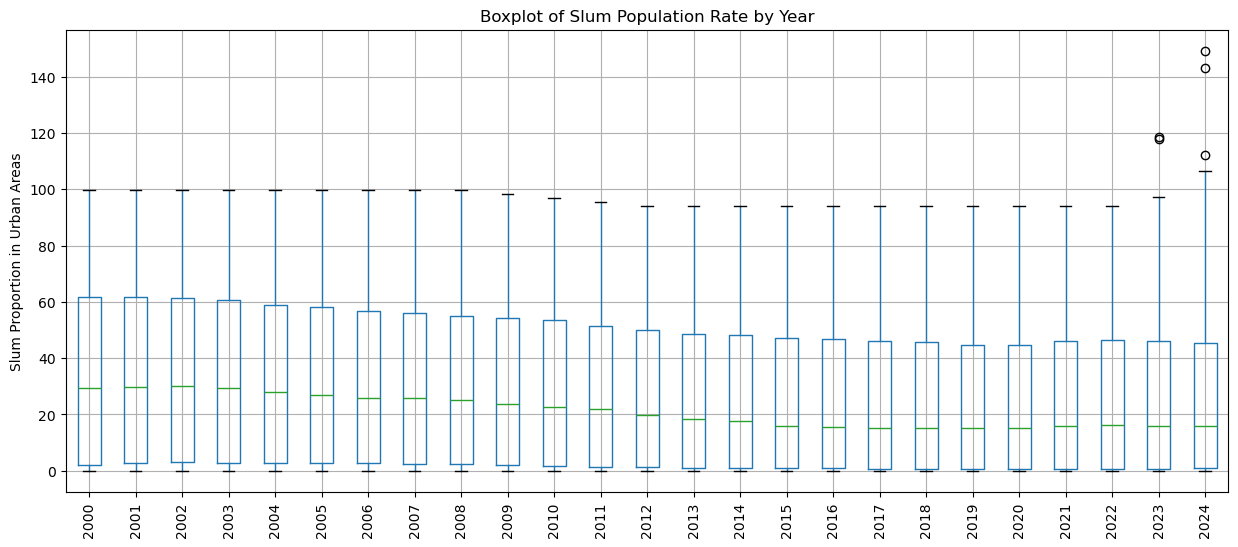

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

slum_df[years_2000_2024].boxplot()

plt.xticks(rotation=90)
plt.ylabel("Slum Proportion in Urban Areas")
plt.title("Boxplot of Slum Population Rate by Year")

plt.show()

Values Above 100% Before Capping:


,GeoAreaName,SlumProportion,Year,CapValue
29,Burkina Faso,118.54750,2023,100
117,Mali,117.78104,2023,100
29,Burkina Faso,149.21325,2024,100
45,Congo,106.50107,2024,100
117,Mali,143.06511,2024,100
166,Sao Tome and Principe,112.18666,2024,100
200,Tuvalu,100.90916,2024,100


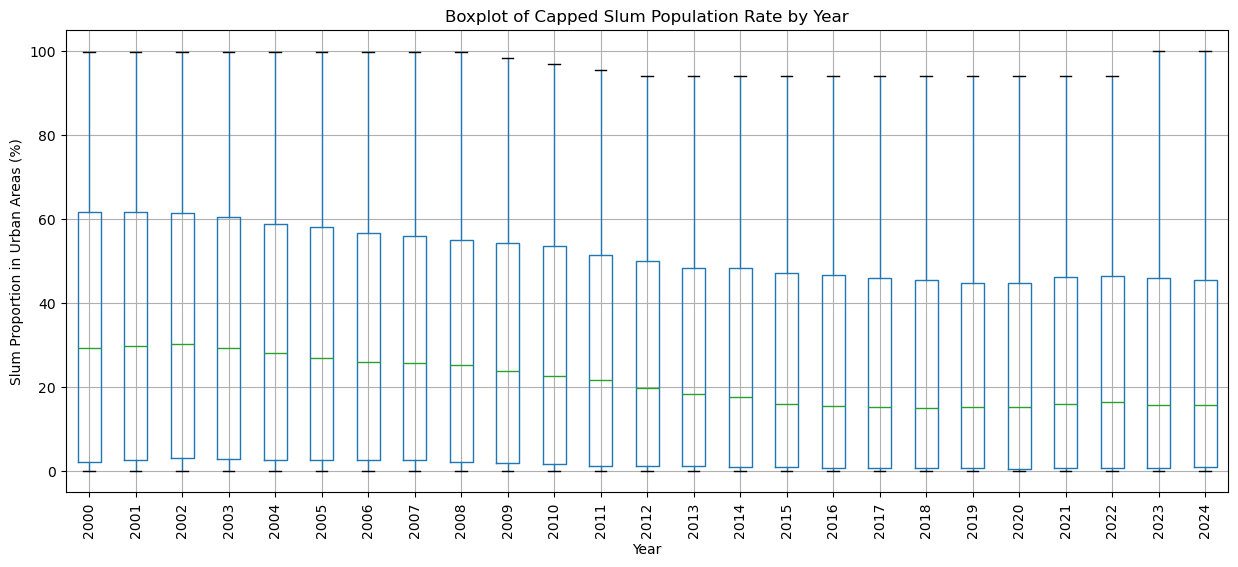

In [128]:
# Store values above 100%
slum_possible_outliers = []

for year in years_2000_2024:

    # Skip missing year columns
    if year not in slum_df.columns:
        continue

    # Get values above 100
    outliers = slum_df[
        slum_df[year] > 100
    ][['GeoAreaName', year]].copy()

    outliers = outliers.rename(
        columns={year: 'SlumProportion'}
    )

    outliers['Year'] = year
    outliers['CapValue'] = 100

    slum_possible_outliers.append(outliers)

# Combine all outliers
slum_possible_outliers_df = pd.concat(
    slum_possible_outliers
)

print("Values Above 100% Before Capping:")
display(slum_possible_outliers_df)

# -----------------------------
# Apply 100% upper capping
# -----------------------------
slum_df_capped = slum_df.copy()

for year in years_2000_2024:

    # Skip missing year columns
    if year not in slum_df_capped.columns:
        continue

    # Cap values above 100
    slum_df_capped[year] = slum_df_capped[year].clip(
        upper=100
    )

# Replace original dataset
slum_df = slum_df_capped

# Boxplot after capping
plt.figure(figsize=(15, 6))

slum_df.boxplot(
    column=years_2000_2024,
    rot=90
)

plt.title('Boxplot of Capped Slum Population Rate by Year')
plt.xlabel('Year')
plt.ylabel('Slum Proportion in Urban Areas (%)')

plt.grid(True)

plt.show()

During the outlier inspection, I noticed that some values in the slum population dataset exceeded 100%, which is not realistically possible for a percentage-based indicator. Since this dataset measures the proportion of the urban population living in slums, values above 100% are more likely caused by reporting inconsistencies, estimation issues, or differences in data collection methods rather than genuine real-world conditions.

In my opinion, keeping these values unchanged would make the dataset unrealistic and could negatively affect the later normalisation stage of the composite indicator. Because of this, I decided to cap all values above 100 at 100 rather than removing the countries entirely. 

I personally felt this was the best approach because it keeps the observations within realistic limits while still preserving countries that genuinely have very high slum population proportions.


#### disaster_df

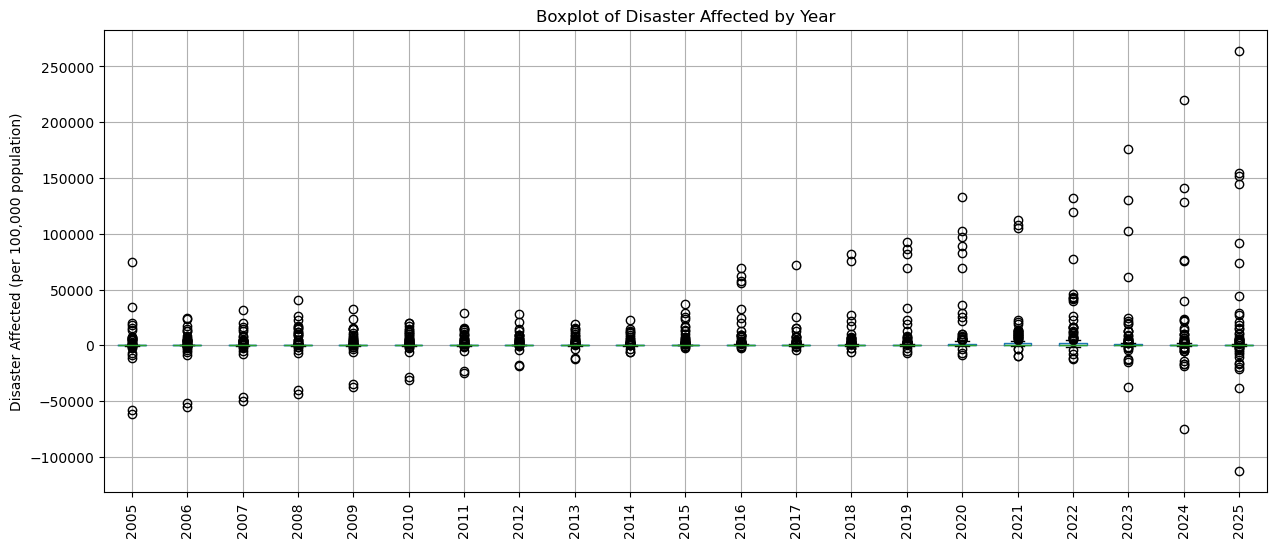

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

disaster_df[years_2005_2025].boxplot()

plt.xticks(rotation=90)
plt.ylabel("Disaster Affected (per 100,000 population)")
plt.title("Boxplot of Disaster Affected by Year")

plt.show()

Negative Values Before Treatment:


,GeoAreaName,DisasterRiskRate,Year,ReplacementValue
19,Botswana,-90.336342,2005,0
38,Czechia,-12.588933,2005,0
41,Dominica,-609.884849,2005,0
45,Equatorial Guinea,-0.309512,2005,0
51,France,-4.366165,2005,0
...,...,...,...,...
147,Trinidad and Tobago,-1460.535255,2025,0
159,Uzbekistan,-285.262856,2025,0
160,Vanuatu,-380.312713,2025,0
161,Venezuela (Bolivarian Republic of),-19.298590,2025,0


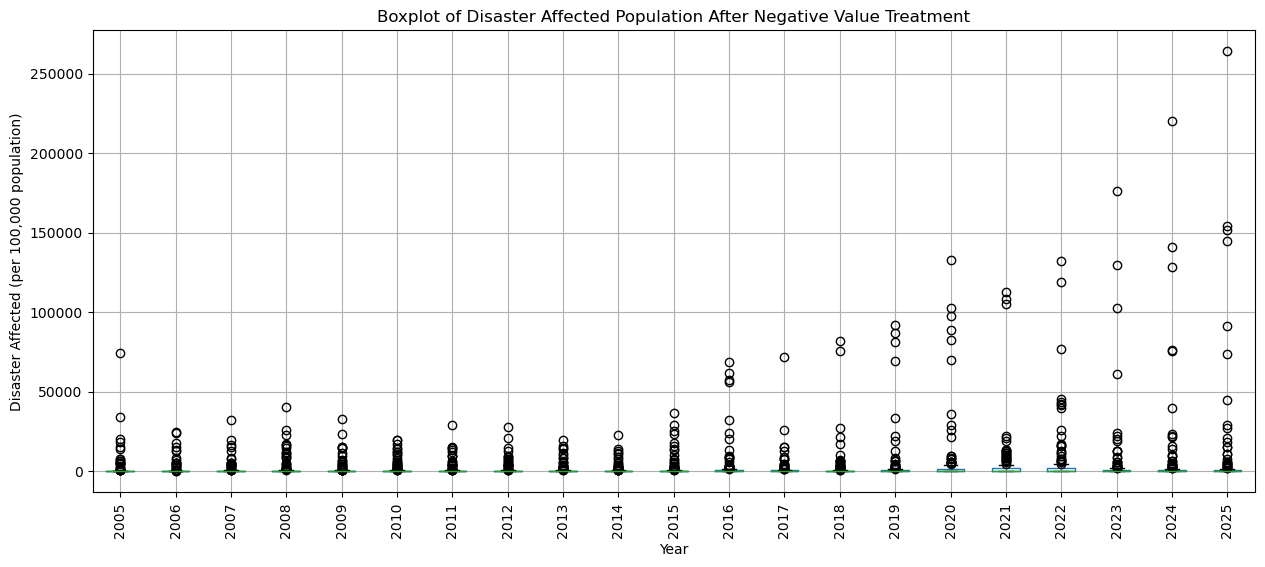

In [130]:
# Store negative values
disaster_possible_outliers = []

for year in years_2005_2025:

    # Skip missing year columns
    if year not in disaster_df.columns:
        continue

    # Get negative values
    outliers = disaster_df[
        disaster_df[year] < 0
    ][['GeoAreaName', year]].copy()

    outliers = outliers.rename(
        columns={year: 'DisasterRiskRate'}
    )

    outliers['Year'] = year
    outliers['ReplacementValue'] = 0

    disaster_possible_outliers.append(outliers)

# Combine all negative outliers
disaster_possible_outliers_df = pd.concat(
    disaster_possible_outliers
)

print("Negative Values Before Treatment:")
display(disaster_possible_outliers_df)

# -----------------------------
# Replace negative values with 0
# -----------------------------
disaster_df_cleaned = disaster_df.copy()

for year in years_2005_2025:

    # Skip missing year columns
    if year not in disaster_df_cleaned.columns:
        continue

    # Replace negatives with 0
    disaster_df_cleaned[year] = disaster_df_cleaned[year].clip(
        lower=0
    )

# Replace original dataset
disaster_df = disaster_df_cleaned

# Boxplot after treatment
plt.figure(figsize=(15, 6))

disaster_df.boxplot(
    column=years_2005_2025,
    rot=90
)

plt.title('Boxplot of Disaster Affected Population After Negative Value Treatment')
plt.xlabel('Year')
plt.ylabel('Disaster Affected (per 100,000 population)')

plt.grid(True)

plt.show()

For the disaster affected dataset, I decided to keep the extremely high values because disasters naturally create large spikes in the data. Countries affected by floods, droughts, earthquakes, cyclones, or other major disasters can realistically have very high numbers of affected people in certain years. In my opinion, these values represent genuine events and should remain in the dataset.

However, I replaced all negative values with `0` because a negative number of affected people is not logically possible for this type of indicator. I believe these negative values are most likely caused by reporting inconsistencies or data processing issues rather than real observations.

This differs from the `slum_df` dataset. In the slum dataset, values above 100% were capped because percentages cannot realistically exceed 100. For the disaster dataset, there is no realistic upper limit since disaster impacts can vary massively between countries and years. Because of this, I kept the high values but only corrected the impossible negative ones.


### 6.1 Creating New Variables

#### slum_df

In [131]:
import pandas as pd
import numpy as np

# Select 5-year intervals + latest year
slum_forecast_years = ['2005', '2010', '2015', '2020', '2024']

# Temporary forecasting dataframe
slum_forecast_df = slum_df[
    ['GeoAreaName'] + slum_forecast_years
].copy()

# Years for regression
x_years = np.array([2005, 2010, 2015, 2020, 2024])

# Store predictions
predictions_2030 = []

for index, row in slum_forecast_df.iterrows():

    y_values = row[slum_forecast_years].values.astype(float)

    # Skip countries with missing values
    if np.isnan(y_values).any():
        predictions_2030.append(np.nan)
        continue

    # Linear trend
    slope, intercept = np.polyfit(x_years, y_values, 1)

    # Predict 2030
    predicted_2030 = slope * 2030 + intercept

    predictions_2030.append(predicted_2030)

# Create final dataset
slum_2030_df = pd.DataFrame({
    'GeoAreaName': slum_forecast_df['GeoAreaName'],
    'SlumPopulation_2030_Predicted': predictions_2030
})

# Display result
display(slum_2030_df)

,GeoAreaName,SlumPopulation_2030_Predicted
0,Afghanistan,75.339061
1,Albania,-5.932409
2,Algeria,5.469330
3,Andorra,0.000000
4,Angola,81.406761
...,...,...
213,Western Sahara,4.151932
214,World,22.081276
215,Yemen,37.762881
216,Zambia,42.997446


#### disaster_df

In [132]:
# Select 5-year intervals + latest year
disaster_forecast_years = ['2005', '2010', '2015', '2020', '2025']

# Temporary forecasting dataframe
disaster_forecast_df = disaster_df[
    ['GeoAreaName'] + disaster_forecast_years
].copy()

# Years for regression
x_years = np.array([2005, 2010, 2015, 2020, 2025])

# Store predictions
predictions_2030 = []

for index, row in disaster_forecast_df.iterrows():

    y_values = row[disaster_forecast_years].values.astype(float)

    # Skip countries with missing values
    if np.isnan(y_values).any():
        predictions_2030.append(np.nan)
        continue

    # Linear trend
    slope, intercept = np.polyfit(x_years, y_values, 1)

    # Predict 2030
    predicted_2030 = slope * 2030 + intercept

    predictions_2030.append(predicted_2030)

# Create final dataset
disaster_2030_df = pd.DataFrame({
    'GeoAreaName': disaster_forecast_df['GeoAreaName'],
    'DisasterAffected_2030_Predicted': predictions_2030
})

# Display result
display(disaster_2030_df)

,GeoAreaName,DisasterAffected_2030_Predicted
0,Afghanistan,1609.393514
1,Albania,902.918922
2,Algeria,231.992181
4,Angola,119.414922
5,Antigua and Barbuda,1913.023677
...,...,...
160,Vanuatu,39466.196658
161,Venezuela (Bolivarian Republic of),-292.199305
162,Viet Nam,-0.126799
163,Yemen,-2556.458024


To estimate future SDG 11 readiness, I followed the same forecasting approach previously used for SDG 3 and SDG 6. Projected 2030 variables were created using historical trend data for each SDG 11 indicator.

The indicators included:

- Proportion of Urban Population Living in Slums
- Number of Directly Affected Persons Attributed to Disasters per 100,000 Population

For this section, I again used 5-year interval observations:

- 2005
- 2010
- 2015
- 2020

I also included the most recent available year for each dataset:

- 2024 for the slum population dataset
- 2025 for the disaster affected population dataset

The decision to continue using 5-year intervals was mainly influenced by the forecasting structure already established within SDG 3. In my opinion, this created strong methodological consistency across the overall project. This approach also worked well for SDG 11 because the disaster dataset itself only began from 2005, meaning there was no earlier historical data available to include.

Using the same interval structure across the project keeps the forecasting process more consistent and easier to compare between SDG categories.

As with the previous SDGs, a linear regression trend was calculated individually for each country, and this trend was used to estimate the projected indicator value for 2030.

Countries with missing values across the selected forecasting years were excluded from prediction to avoid generating unreliable estimates from incomplete trend data.

The final forecasting datasets only retained:

- `GeoAreaName`
- the projected 2030 indicator variable

Retained in the following:

- slum_2030_df
- disaster_2030_df

This simplified structure was intentionally used because these projected variables will later be merged together when constructing the SDG 11 sub-index.

### 7.1 Multivariate Analysis

#### 7.2 Combining Data

#### 7.3 Heatmap